In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from cellseg_benchmark._constants import method_colors, cell_type_colors, methods_3D

In [2]:
base_path = Path("/Users/jonasflor/Desktop/metrics_benchmark")
gen_stats = pd.read_csv(base_path / "data/general_stats.csv", index_col=0)
comp_ana = pd.read_csv(base_path / "data/cell_type_distribution_adata_integrated_cell_type_revised.csv", index_col=0).melt(id_vars=["method", "sample"], value_vars=["VLMCs", "BAMs", "SMCs", "Neurons-Dopa", "Neurons-Gaba", "Neurons-Glut", "Neurons-Glyc-Gaba", "Neurons-Granule-Immature", "Neurons-Other", 'Astrocytes', "Astroependymal", "ABCs", "OPCs", "Microglia", "ECs", "Pericytes", "Oligodendrocytes", "Undefined", "Immune-Other", "Ependymal", "Choroid-Plexus", "Tanycytes", "OECs", "Low-Read-Cells", "Undefined"], var_name="cell_type_revised", value_name="representation")
assign_tr = pd.read_csv(base_path / "data/assigned_transcript_counts.csv", index_col=0)
marker_f1_stats = pd.read_csv(base_path / "data/marker_f1_score_cell_type_revised.csv", index_col=0)
neg_purity_stats = pd.read_csv(base_path / "data/negative_marker_purity_all.csv", index_col=0)
MECR_stats = pd.read_csv(base_path / "data/MECR_score_all.csv", index_col=0)
clustering_stats = pd.read_csv(base_path / "data/clustering_score_adata_integrated_cell_type_revised.csv", index_col=0)
ficture_f1 = pd.read_csv(base_path / "data/ficture_f1.csv", index_col=0)
marker_f1_stats['cell_type_revised'] = marker_f1_stats['cell_type']

In [7]:
data = {"gen_stats": gen_stats, "comp_ana": comp_ana, "ass_tr": assign_tr, "marker_f1": marker_f1_stats, "neg_purity": neg_purity_stats,
        "MECR": MECR_stats, "Clust_stats": clustering_stats,
        "fict": ficture_f1
        }

for c, d in data.items():
    print(f"{c}: {", ".join(d.columns)}")

gen_stats: method, sample, cell_type_revised, volume_final, area, sphericity, elongation, intensities_PolyT, intensities_DAPI, Ovrlpy_stats_mean_integrity, n_cells
comp_ana: method, sample, cell_type_revised, representation
ass_tr: method, sample, gene, assigned_count_qced, assigned_count_raw, total_count, pct_assigned_raw, pct_assigned_qced
marker_f1: method, sample, cell_type, marker_gene, f1_score, precision, recall, tp, fp, fn, cell_type_revised
neg_purity: method, negative_marker_purity
MECR: method, sample, gene1, gene2, MECR
Clust_stats: method, sample, calinski_harabasz_score, silhouette_score
fict: method, sample, cell_type, tp, fp, fn, TN, f1_score, precision, recall


# Single metric representation

In [56]:
method_order = [x for x in method_colors.keys() if x in gen_stats['method'].unique()]

## gen_stats

<Axes: xlabel='volume_final', ylabel='method'>

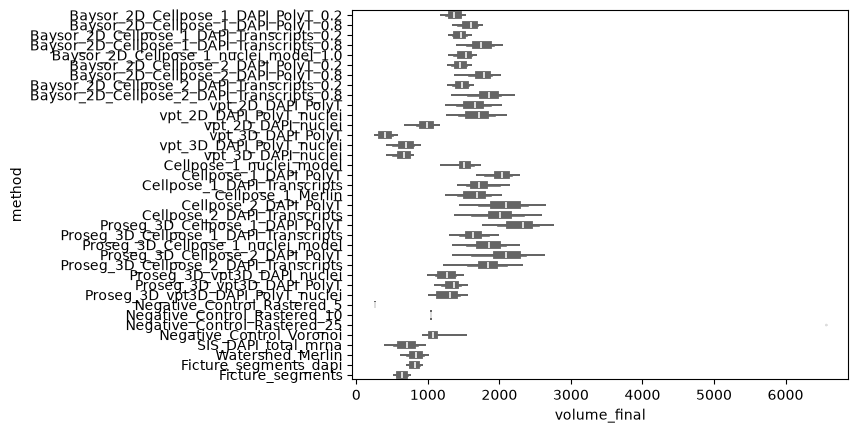

In [57]:
sns.violinplot(gen_stats[gen_stats['cell_type_revised']=="all"], y="method", x="volume_final", order=method_order)

<Axes: xlabel='elongation', ylabel='method'>

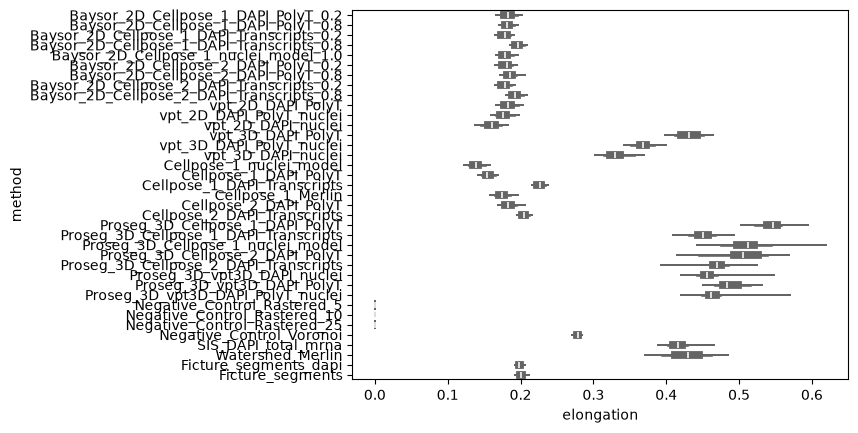

In [58]:
sns.violinplot(gen_stats[gen_stats['cell_type_revised']=="all"], y="method", x="elongation", order=method_order)

<Axes: xlabel='sphericity', ylabel='method'>

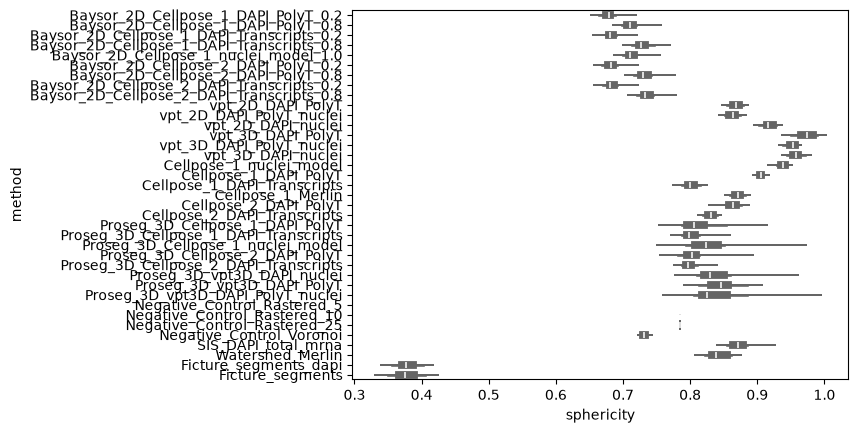

In [59]:
sns.violinplot(gen_stats[gen_stats['cell_type_revised']=="all"], y="method", x="sphericity", order=method_order)

/var/folders/b7/2447cny161d6nzl8rj07yssr0000gn/T/ipykernel_3921/4119689053.py:3: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  ovrlpy_mask = ovrlpy_mask_1 & ovrlpy_mask_2


<Axes: xlabel='Ovrlpy_stats_mean_integrity', ylabel='method'>

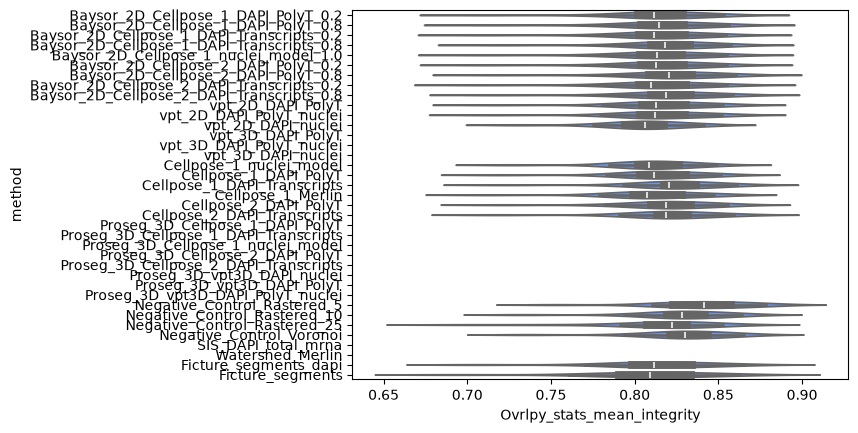

In [60]:
ovrlpy_mask_1 = [not any([x.startswith(y) for y in methods_3D]) for x in gen_stats['method']]
ovrlpy_mask_2 = gen_stats['cell_type_revised']=="all"
ovrlpy_mask = ovrlpy_mask_1 & ovrlpy_mask_2
sns.violinplot(gen_stats[ovrlpy_mask], y="method", x="Ovrlpy_stats_mean_integrity", order=method_order)

<Axes: xlabel='intensities_PolyT', ylabel='method'>

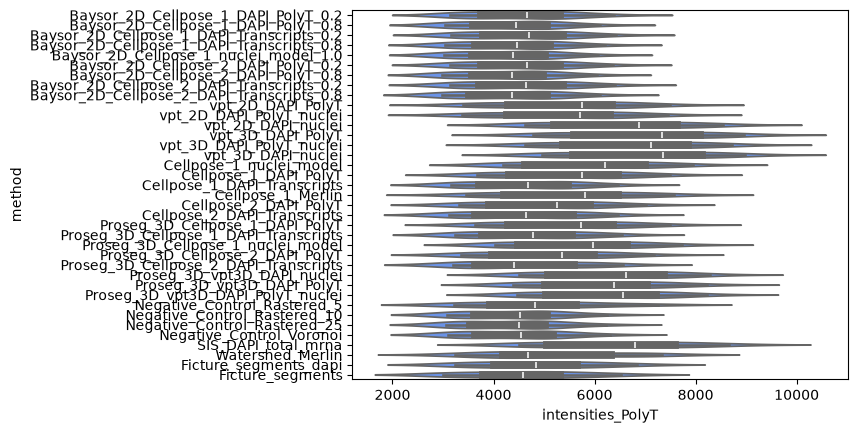

In [61]:
sns.violinplot(gen_stats[gen_stats['cell_type_revised']=="all"], y="method", x="intensities_PolyT", order=method_order)

<Axes: xlabel='intensities_DAPI', ylabel='method'>

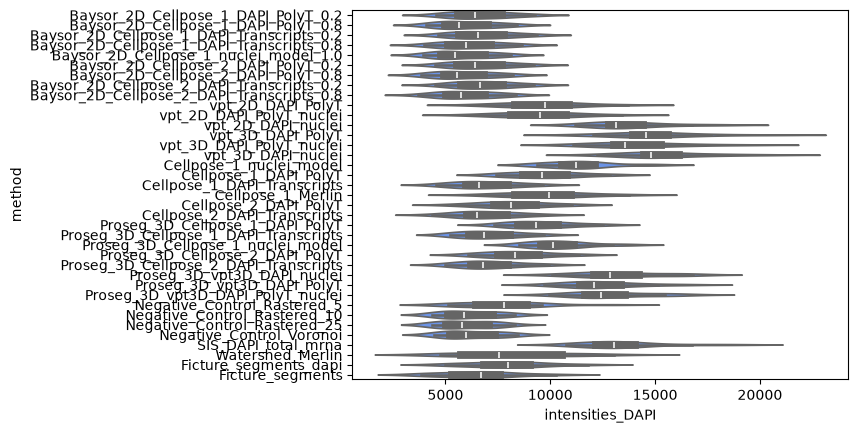

In [62]:
sns.violinplot(gen_stats[gen_stats['cell_type_revised']=="all"], y="method", x="intensities_DAPI", order=method_order)

## ficture f1

<Axes: xlabel='f1_score', ylabel='method'>

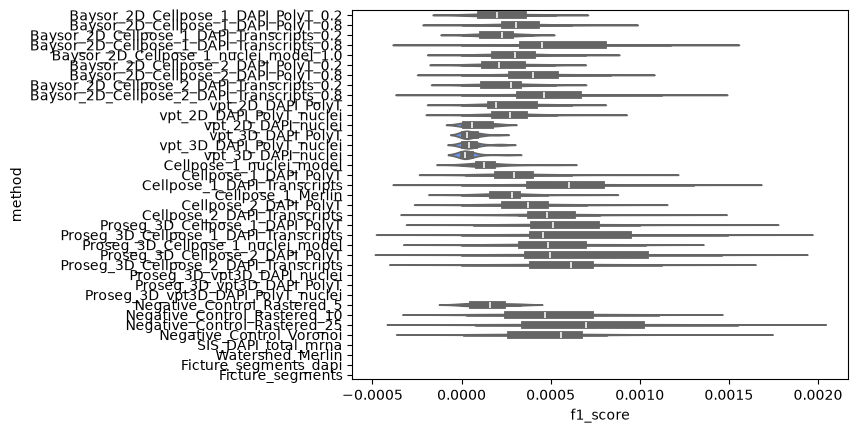

In [63]:
sns.violinplot(ficture_f1[ficture_f1['cell_type']=="ECs"], y="method", x="f1_score", order=method_order)

## marker_f1_stats

<Axes: xlabel='f1_score', ylabel='method'>

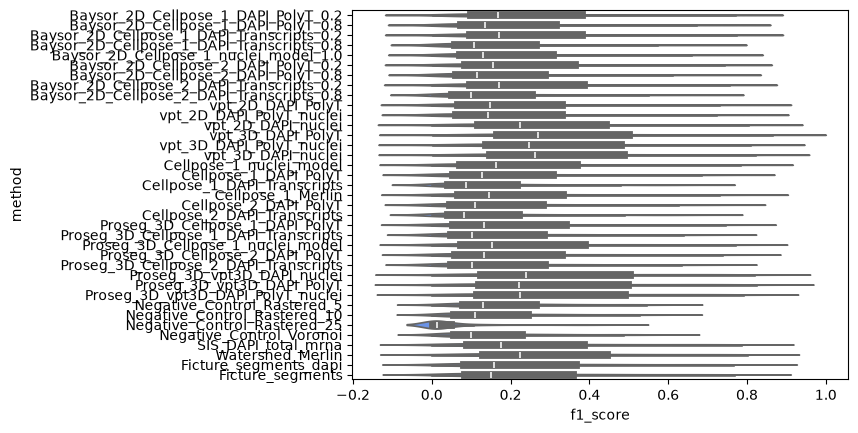

In [64]:
sns.violinplot(marker_f1_stats[marker_f1_stats['cell_type']=="ECs"], y="method", x="f1_score", order=method_order)

## MECR_stats

In [67]:
MECR_order = MECR_stats.groupby("method").agg(mean_MECR = ("MECR", "mean")).reset_index().sort_values("mean_MECR", ascending=False)['method']

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Negative_Control_Rastered_25'),
  Text(1, 0, 'Proseg_3D_Cellpose_1_DAPI_PolyT'),
  Text(2, 0, 'Proseg_3D_Cellpose_1_nuclei_model'),
  Text(3, 0, 'Cellpose_2_DAPI_PolyT'),
  Text(4, 0, 'Cellpose_1_DAPI_PolyT'),
  Text(5, 0, 'Proseg_3D_vpt3D_DAPI_PolyT'),
  Text(6, 0, 'Proseg_3D_vpt3D_DAPI_PolyT_nuclei'),
  Text(7, 0, 'Cellpose_2_DAPI_Transcripts'),
  Text(8, 0, 'Proseg_3D_vpt3D_DAPI_nuclei'),
  Text(9, 0, 'Proseg_3D_Cellpose_2_DAPI_PolyT'),
  Text(10, 0, 'Cellpose_1_nuclei_model'),
  Text(11, 0, 'vpt_2D_DAPI_PolyT_nuclei'),
  Text(12, 0, 'Cellpose_1_Merlin'),
  Text(13, 0, 'Cellpose_1_DAPI_Transcripts'),
  Text(14, 0, 'SIS_DAPI_total_mrna'),
  Text(15, 0, 'vpt_2D_DAPI_PolyT'),
  Text(16, 0, 'Proseg_3D_Cellpose_2_DAPI_Transcripts'),
  Text(17, 0, 'Proseg_3D_Cellpos

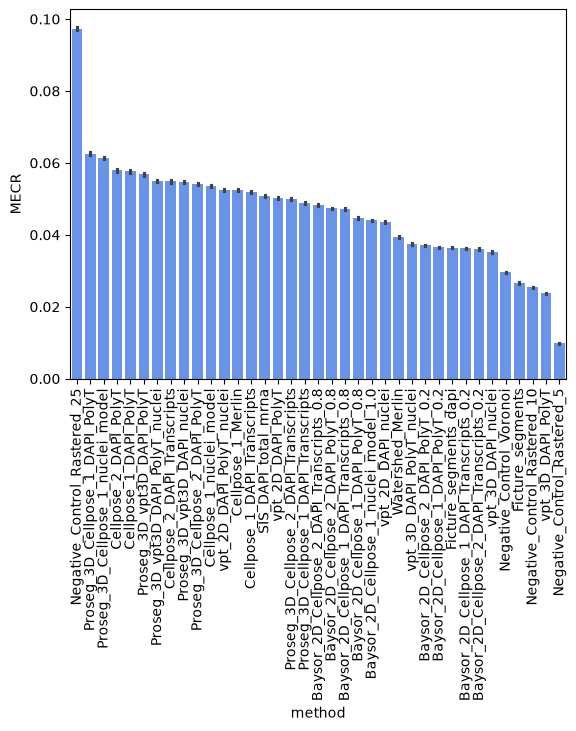

In [70]:
sns.barplot(MECR_stats, y="MECR", x="method", order=MECR_order)
plt.xticks(rotation=90)

## neg_purity_stats

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Negative_Control_Rastered_25'),
  Text(1, 0, 'Cellpose_1_DAPI_PolyT'),
  Text(2, 0, 'Cellpose_1_Merlin'),
  Text(3, 0, 'Cellpose_1_nuclei_model'),
  Text(4, 0, 'vpt_2D_DAPI_PolyT_nuclei'),
  Text(5, 0, 'vpt_2D_DAPI_PolyT'),
  Text(6, 0, 'Proseg_3D_Cellpose_1_DAPI_PolyT'),
  Text(7, 0, 'Cellpose_2_DAPI_PolyT'),
  Text(8, 0, 'Proseg_3D_Cellpose_1_nuclei_model'),
  Text(9, 0, 'SIS_DAPI_total_mrna'),
  Text(10, 0, 'vpt_2D_DAPI_nuclei'),
  Text(11, 0, 'Cellpose_2_DAPI_Transcripts'),
  Text(12, 0, 'Proseg_3D_Cellpose_2_DAPI_PolyT'),
  Text(13, 0, 'Cellpose_1_DAPI_Transcripts'),
  Text(14, 0, 'Proseg_3D_Cellpose_2_DAPI_Transcripts'),
  Text(15, 0, 'vpt_3D_DAPI_PolyT_nuclei'),
  Text(16, 0, 'Proseg_3D_vpt3D_DAPI_PolyT'),
  Text(17, 0, 'Watershed_Merlin'),
  Text(18, 0, '

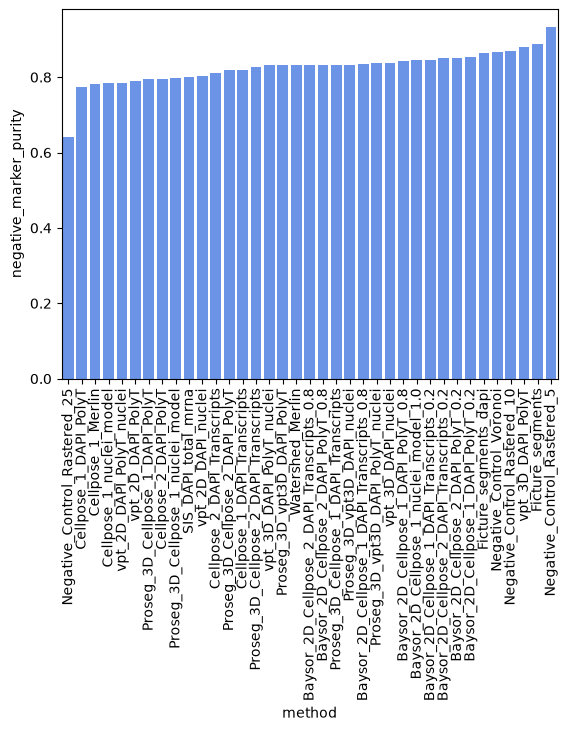

In [73]:
neg_purity_order = neg_purity_stats.groupby("method").agg(mean_negative_marker_purity = ("negative_marker_purity", "mean")).reset_index().sort_values("mean_negative_marker_purity", ascending=True)['method']
sns.barplot(neg_purity_stats, y="negative_marker_purity", x="method", order=neg_purity_order)
plt.xticks(rotation=90)

## comp_ana

<Axes: xlabel='representation', ylabel='method'>

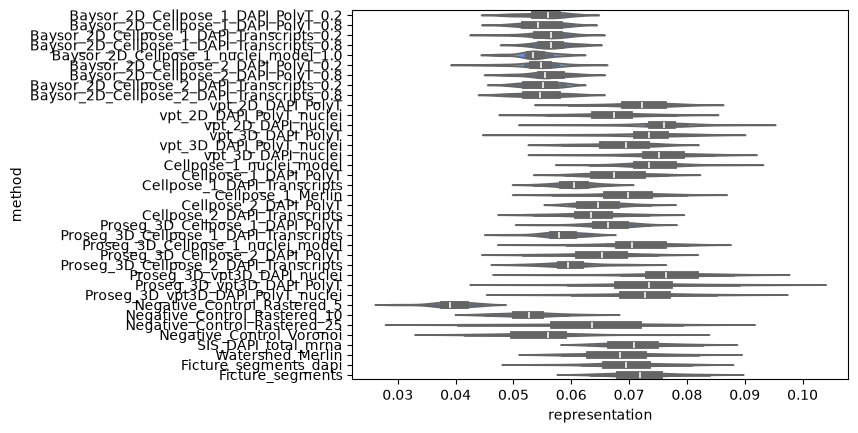

In [74]:
sns.violinplot(comp_ana[comp_ana['cell_type_revised']=="ECs"], y="method", x="representation", order=method_order)

<Axes: xlabel='representation', ylabel='method'>

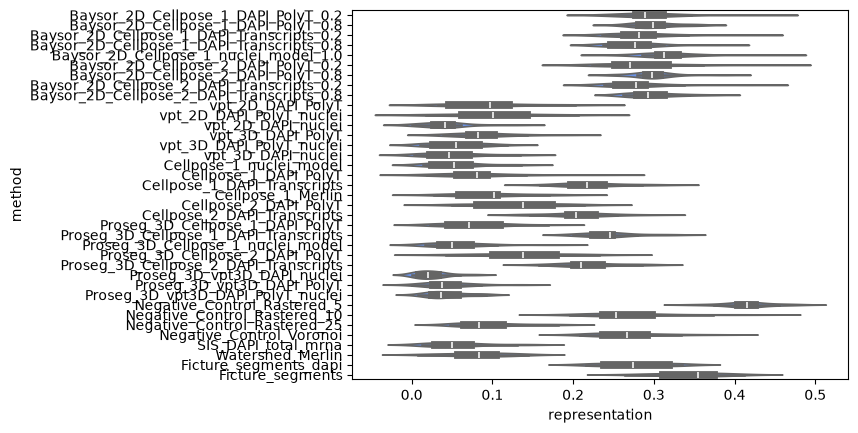

In [78]:
sns.violinplot(comp_ana[comp_ana['cell_type_revised']=="Undefined"], y="method", x="representation", order=method_order)

## clustering_stats

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Negative_Control_Rastered_5'),
  Text(1, 0, 'Negative_Control_Rastered_10'),
  Text(2, 0, 'Negative_Control_Voronoi'),
  Text(3, 0, 'Ficture_segments'),
  Text(4, 0, 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2'),
  Text(5, 0, 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8'),
  Text(6, 0, 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8'),
  Text(7, 0, 'Baysor_2D_Cellpose_1_nuclei_model_1.0'),
  Text(8, 0, 'Cellpose_1_DAPI_Transcripts'),
  Text(9, 0, 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8'),
  Text(10, 0, 'Negative_Control_Rastered_25'),
  Text(11, 0, 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8'),
  Text(12, 0, 'Ficture_segments_dapi'),
  Text(13, 0, 'Cellpose_2_DAPI_Transcripts'),
  Text(14, 0, 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.2'),
  Text(15, 0, 'Proseg_3D_Cellpose_1_DAPI_Transcripts'),

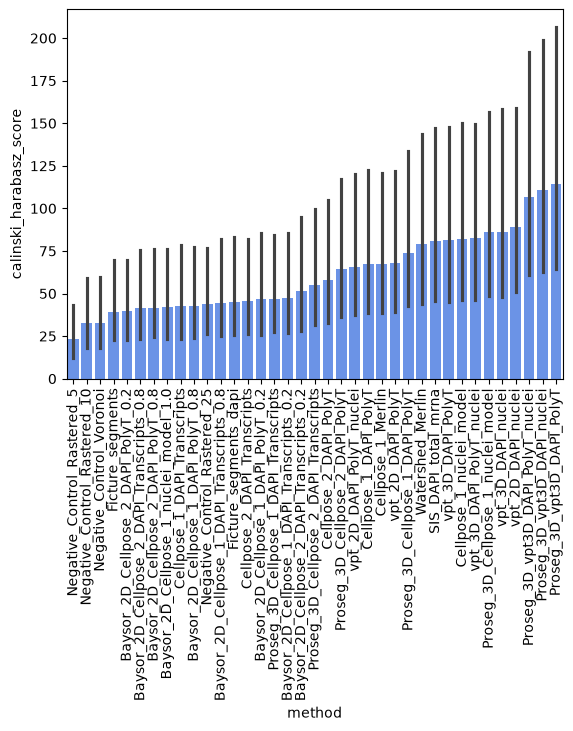

In [80]:
clustering_order = clustering_stats.groupby("method").agg(mean_CH = ("calinski_harabasz_score", "mean")).reset_index().sort_values("mean_CH", ascending=True)['method']
sns.barplot(clustering_stats, y="calinski_harabasz_score", x="method", order=clustering_order)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Negative_Control_Rastered_5'),
  Text(1, 0, 'Negative_Control_Rastered_10'),
  Text(2, 0, 'Negative_Control_Voronoi'),
  Text(3, 0, 'Baysor_2D_Cellpose_1_nuclei_model_1.0'),
  Text(4, 0, 'Baysor_2D_Cellpose_2_DAPI_Transcripts_0.8'),
  Text(5, 0, 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.8'),
  Text(6, 0, 'Ficture_segments'),
  Text(7, 0, 'Baysor_2D_Cellpose_1_DAPI_PolyT_0.8'),
  Text(8, 0, 'Cellpose_2_DAPI_Transcripts'),
  Text(9, 0, 'Proseg_3D_Cellpose_2_DAPI_Transcripts'),
  Text(10, 0, 'Cellpose_1_DAPI_Transcripts'),
  Text(11, 0, 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.2'),
  Text(12, 0, 'Baysor_2D_Cellpose_1_DAPI_Transcripts_0.2'),
  Text(13, 0, 'Baysor_2D_Cellpose_2_DAPI_PolyT_0.8'),
  Text(14, 0, 'Proseg_3D_Cellpose_1_DAPI_Transcripts'),
  Text(15, 0, 'Negative_

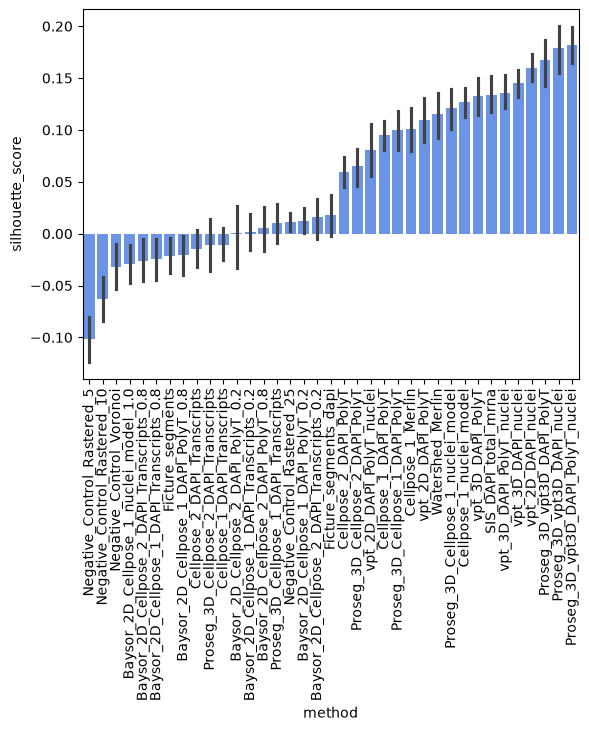

In [81]:
sil_order = clustering_stats.groupby("method").agg(mean_sil = ("silhouette_score", "mean")).reset_index().sort_values("mean_sil", ascending=True)['method']
sns.barplot(clustering_stats, y="silhouette_score", x="method", order=sil_order)
plt.xticks(rotation=90)

In [18]:
MECR_stats_transformed = MECR_stats.groupby(["method", "sample"]).agg(MECR_mean = ("MECR", "mean"), MECR_std = ("MECR", "std")).reset_index()
MECR_stats_transformed

,method,sample,MECR_mean,MECR_std
0,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,0.033246,0.017865
1,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r1,0.047055,0.023219
2,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r2,0.043087,0.022182
3,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s11_r0,0.033943,0.017701
4,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s11_r1,0.030404,0.015941
...,...,...,...,...
581,vpt_3D_DAPI_nuclei,aging_s7_r1,0.021214,0.014291
582,vpt_3D_DAPI_nuclei,aging_s7_r2,0.031744,0.020309
583,vpt_3D_DAPI_nuclei,aging_s8_r0,0.043218,0.024431
584,vpt_3D_DAPI_nuclei,aging_s8_r1,0.047711,0.027659


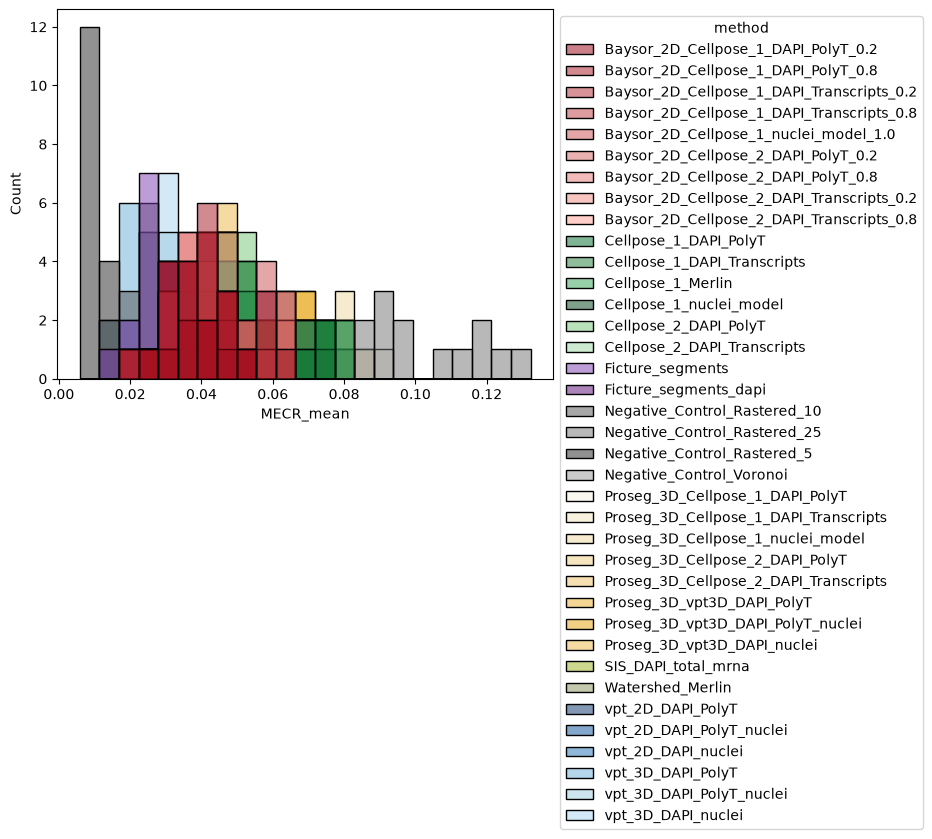

In [21]:
ax = sns.histplot(MECR_stats_transformed, x="MECR_mean", hue="method", palette=method_colors)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: xlabel='method', ylabel='negative_marker_purity'>

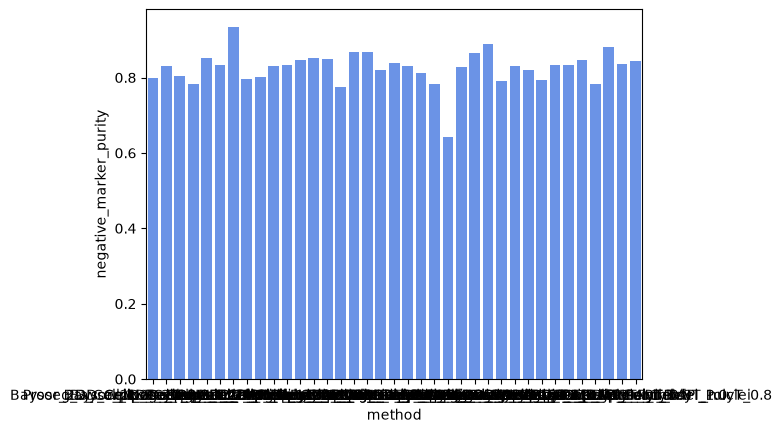

In [13]:
sns.barplot(neg_purity_stats, y="negative_marker_purity", x="method")

<Axes: xlabel='f1_score', ylabel='Count'>

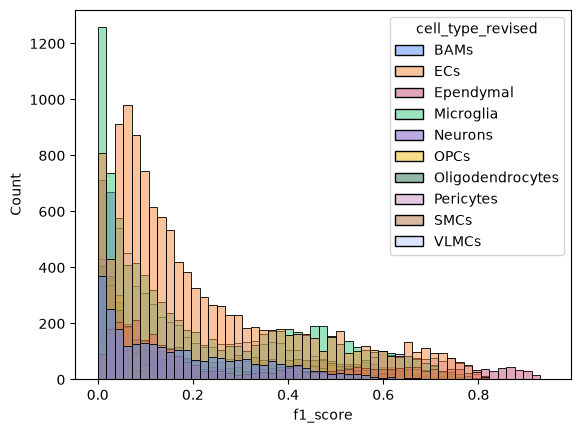

In [9]:
sns.histplot(marker_f1_stats, x="f1_score", hue="cell_type_revised")

In [23]:
combined_data = (gen_stats.merge(comp_ana, on=["method", "sample", "cell_type_revised"], how="outer")
                 .merge(marker_f1_stats, on=["method", "sample", "cell_type_revised"], how="outer", suffixes=("", "_marker"))
                 #.merge(ficture, on=["method", "sample", "cell_type_revised"], how="outer")+
                )
combined_data

,method,sample,cell_type_revised,volume_final,area,sphericity,elongation,intensities_PolyT,intensities_DAPI,Ovrlpy_stats_mean_integrity,n_cells,representation,cell_type,marker_gene,f1_score,precision,recall,tp,fp,fn
0,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,ABCs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,Astrocytes,1418.356922,135.081612,0.662037,0.171063,3117.037471,4926.209479,0.806699,NaN,0.114906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,Astroependymal,1572.373448,149.749852,0.684460,0.168840,2976.064363,4854.801807,0.867563,NaN,0.028482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,BAMs,1703.568344,162.244604,0.719872,0.165835,3386.542764,6943.592087,0.905641,NaN,0.016045,BAMs,Mrc1,0.167604,0.327546,0.112614,283.0,581.0,2230.0
4,Baysor_2D_Cellpose_1_DAPI_PolyT_0.2,aging_s10_r0,BAMs,1703.568344,162.244604,0.719872,0.165835,3386.542764,6943.592087,0.905641,NaN,0.016045,BAMs,Pf4,0.034470,0.219626,0.018703,47.0,167.0,2466.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56449,vpt_3D_DAPI_nuclei,all,Pericytes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.021176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56450,vpt_3D_DAPI_nuclei,all,SMCs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56451,vpt_3D_DAPI_nuclei,all,Tanycytes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56452,vpt_3D_DAPI_nuclei,all,Undefined,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.052161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import math

metrics = ["volume_final", "area", "sphericity", "elongation", "intensities_PolyT", "Ovrlpy_stats_mean_integrity", "representation",
           "f1_score"
           ]

for ct in combined_data['cell_type_revised'].unique():
    tmp = combined_data[combined_data['cell_type_revised'] == ct]

    pairs = list(itertools.product(metrics, metrics))
    n_plots = len(pairs)
    ncols = len(metrics)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.2 * ncols, 3.0 * nrows)
    )
    axes = axes.ravel()
    for ax, (m1, m2) in zip(axes, pairs):
        sns.scatterplot(
            data=tmp,
            x=m1,
            y=m2,
            hue="sample",
            ax=ax,
            s=20,
            alpha=0.8,
            legend=False,
        )
        ax.set_title(f"{m1} vs {m2}", fontsize=8)
        ax.tick_params(axis="x", labelrotation=45)

    for ax in axes[len(pairs):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="sample", loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle(f"Cell type: {ct}", y=1.02, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.88, 0.98])
    plt.savefig(base_path / f"Plot_metrics/260904_overview_plot_sample_{ct}.svg")

In [ ]:
import math

metrics = ["volume_final", "area", "sphericity", "elongation", "intensities_PolyT", "Ovrlpy_stats_mean_integrity", "representation",
           "f1_score"
           ]

for ct in combined_data['cell_type_revised'].unique():
    tmp = combined_data[combined_data['cell_type_revised'] == ct]

    pairs = list(itertools.product(metrics, metrics))
    n_plots = len(pairs)
    ncols = len(metrics)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.2 * ncols, 3.0 * nrows)
    )
    axes = axes.ravel()
    for ax, (m1, m2) in zip(axes, pairs):
        sns.scatterplot(
            data=tmp,
            x=m1,
            y=m2,
            hue="method",
            palette=method_colors,
            ax=ax,
            s=20,
            alpha=0.8,
            legend=False,
        )
        ax.set_title(f"{m1} vs {m2}", fontsize=8)
        ax.tick_params(axis="x", labelrotation=45)

    for ax in axes[len(pairs):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="sample", loc="upper left", bbox_to_anchor=(1.02, 1))
    fig.suptitle(f"Cell type: {ct}", y=1.02, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.88, 0.98])
    plt.savefig(base_path / f"Plot_metrics/260904_overview_plot_method_{ct}.svg")